# 06 — Spatial Residual Analysis

Maps per-tile mean prediction error back to vineyard geometry.
Systematic spatial clustering in residuals reveals missing variables
(irrigation zones, row orientation, windbreaks, frost pockets, etc.).

- Signed residual map: where does the model over/under-predict?
- Absolute residual map: where is the model most uncertain?
- Residual distribution + Moran's I proxy (spatial autocorrelation)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.spatial import cKDTree

os.environ.setdefault('JAVA_HOME', '/usr/lib/jvm/java-17-openjdk-amd64')
os.environ['PYSPARK_PYTHON']        = '/home/simonhans/anaconda3/envs/GrapeExpectationsML/bin/python'
os.environ['PYSPARK_DRIVER_PYTHON'] = '/home/simonhans/anaconda3/envs/GrapeExpectationsML/bin/python'

PARQUET   = '../data/spark/assembled_v2'
MODEL_DIR = '../data/spark/models_v2'
GEOJSON   = '../data/polygons/tiles_100m2.geojson'
IMG_DIR   = '../data/spark'

os.makedirs(IMG_DIR, exist_ok=True)

In [2]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
    .appName('GrapeExpectations-v2-SpatialResiduals')
    .master('local[*]')
    .config('spark.driver.memory', '10g')
    .config('spark.driver.maxResultSize', '2g')
    .config('spark.sql.shuffle.partitions', '200')
    .getOrCreate())

spark.sparkContext.setLogLevel('WARN')
print('Spark version:', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/19 13:08:04 WARN Utils: Your hostname, sbook, resolves to a loopback address: 127.0.1.1; using 192.168.88.6 instead (on interface wlp2s0)
26/08/19 13:08:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/19 13:08:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


In [3]:
from pyspark.ml import PipelineModel
from pyspark.sql import functions as F

TARGET = 'ndvi_anomaly_harvest'

df = spark.read.parquet(PARQUET)
print(f'Loaded: {df.count():,} rows x {len(df.columns)} cols')

gbt_model = PipelineModel.load(os.path.join(MODEL_DIR, 'gbt'))

# Apply to full dataset (all years, all tiles)
preds = gbt_model.transform(df.dropna(subset=[TARGET]))
residuals = (
    preds
    .select('tile_id', 'year', TARGET, 'prediction')
    .withColumn('residual', F.col('prediction') - F.col(TARGET))
    .withColumn('abs_residual', F.abs(F.col('residual')))
)

# Aggregate per tile across all years
tile_res = (
    residuals
    .groupBy('tile_id')
    .agg(
        F.mean('residual').alias('mean_residual'),
        F.mean('abs_residual').alias('mean_abs_residual'),
        F.count('residual').alias('n_years'),
    )
    .toPandas()
)

print(f'Tiles with residuals: {len(tile_res):,}')
print(f'Residual range: {tile_res.mean_residual.min():.4f} to {tile_res.mean_residual.max():.4f}')
print(f'Mean absolute residual: {tile_res.mean_abs_residual.mean():.4f}')

Loaded: 330,280 rows x 419 cols


26/08/19 13:08:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Tiles with residuals: 33,028
Residual range: -0.1547 to 0.1062
Mean absolute residual: 0.0228


In [4]:
# Load tile centroids from GeoJSON
with open(GEOJSON) as f:
    gj = json.load(f)

def poly_centroid(coords):
    arr = np.array(coords[0])  # exterior ring
    return arr[:, 0].mean(), arr[:, 1].mean()

records = []
for feat in gj['features']:
    tid = feat['properties']['tile_id']
    geom = feat['geometry']
    coords = geom['coordinates'] if geom['type'] == 'Polygon' else geom['coordinates'][0]
    cx, cy = poly_centroid(coords)
    records.append({'tile_id': tid, 'lon': cx, 'lat': cy})

centroids = pd.DataFrame(records)
print(f'Centroids loaded: {len(centroids):,}')

# Merge with residuals
plot_df = centroids.merge(tile_res, on='tile_id', how='inner')
print(f'Merged: {len(plot_df):,} tiles')

Centroids loaded: 33,028
Merged: 33,028 tiles


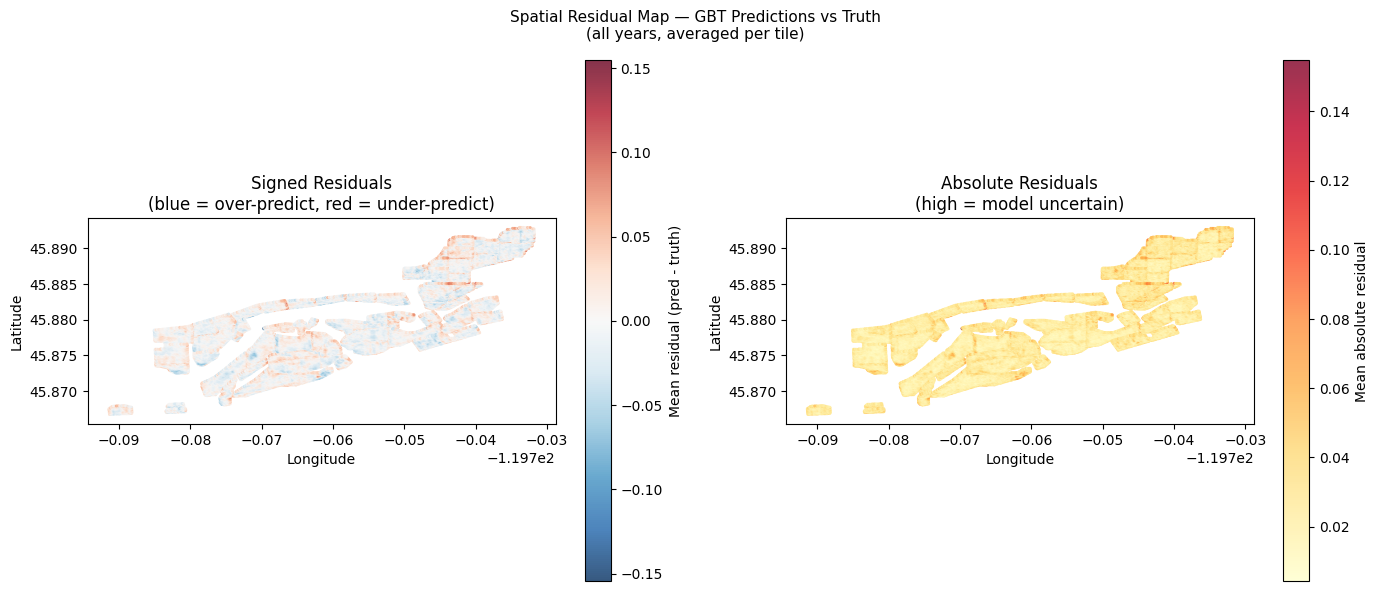

Saved spatial_residuals.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: signed residual
ax = axes[0]
vmax = np.abs(plot_df['mean_residual'].values).max()
norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
sc = ax.scatter(
    plot_df['lon'], plot_df['lat'],
    c=plot_df['mean_residual'], cmap='RdBu_r',
    norm=norm, s=4, alpha=0.8, linewidths=0
)
plt.colorbar(sc, ax=ax, label='Mean residual (pred - truth)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Signed Residuals\n(blue = over-predict, red = under-predict)')
ax.set_aspect('equal')

# Right: absolute residual
ax2 = axes[1]
sc2 = ax2.scatter(
    plot_df['lon'], plot_df['lat'],
    c=plot_df['mean_abs_residual'], cmap='YlOrRd',
    s=4, alpha=0.8, linewidths=0
)
plt.colorbar(sc2, ax=ax2, label='Mean absolute residual')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Absolute Residuals\n(high = model uncertain)')
ax2.set_aspect('equal')

plt.suptitle('Spatial Residual Map — GBT Predictions vs Truth\n(all years, averaged per tile)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'spatial_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved spatial_residuals.png')

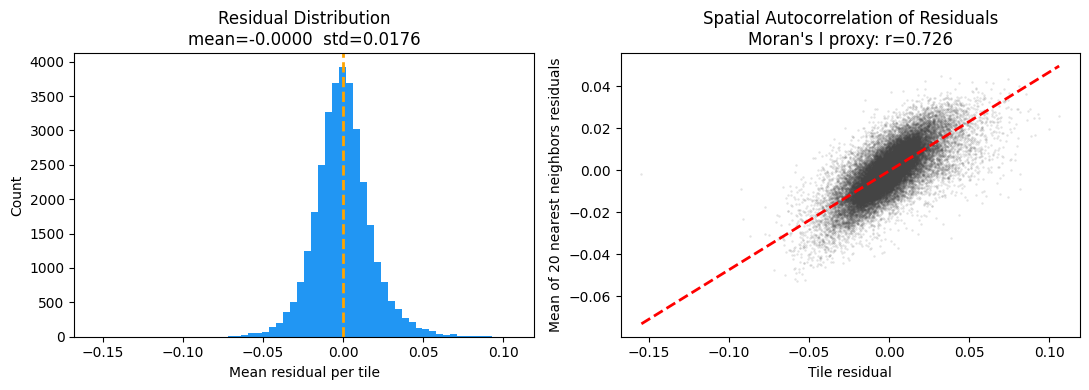

Moran's I proxy: 0.7261


In [6]:
# Residual distribution + spatial autocorrelation (Moran's I proxy)
# Use cKDTree for O(n log n) nearest-neighbor lookup — brute force is too slow at 33k tiles

resid = plot_df['mean_residual'].values
coords = plot_df[['lon', 'lat']].values

k = 20
tree = cKDTree(coords)
_, nn_idx = tree.query(coords, k=k + 1)  # +1 because first result is the point itself
nn_idx = nn_idx[:, 1:]                   # drop self
spatial_lag = resid[nn_idx].mean(axis=1)

r_moran = np.corrcoef(resid, spatial_lag)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(resid, bins=60, color='#2196F3', edgecolor='none')
axes[0].axvline(0, color='orange', linewidth=2, linestyle='--')
axes[0].set_xlabel('Mean residual per tile')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Residual Distribution\nmean={resid.mean():.4f}  std={resid.std():.4f}')

axes[1].scatter(resid, spatial_lag, alpha=0.15, s=3, color='#444', linewidths=0)
m = np.polyfit(resid, spatial_lag, 1)
x_line = np.linspace(resid.min(), resid.max(), 100)
axes[1].plot(x_line, np.polyval(m, x_line), 'r--', linewidth=2)
axes[1].set_xlabel('Tile residual')
axes[1].set_ylabel(f'Mean of {k} nearest neighbors residuals')
axes[1].set_title(f"Spatial Autocorrelation of Residuals\nMoran's I proxy: r={r_moran:.3f}")

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'spatial_residuals_diag.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Moran's I proxy: {r_moran:.4f}")

Test set (held out, n=65,737): R²=0.8950 RMSE=0.03164


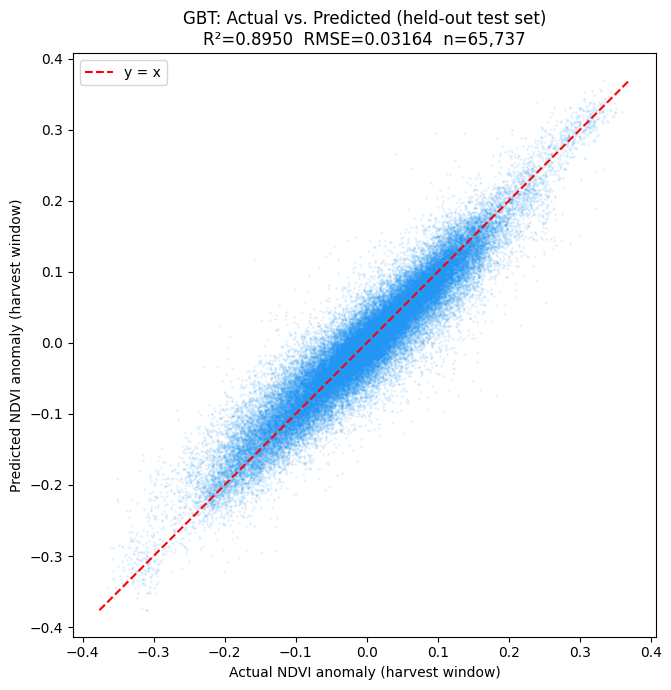

Saved gbt_actual_vs_predicted.png


In [7]:
from pyspark.ml.evaluation import RegressionEvaluator

# Actual vs. predicted on the HELD-OUT TEST SET -- not the full-dataset
# residual maps above (those are intentionally whole-vineyard). Reproduces
# 05_spark_ml.ipynb's exact feature_cols and train/test split (same
# seed=42) so this is a fair generalization check, matching how R²=0.8950
# was actually computed, not train-set leakage.
feature_wks = list(range(1, 36))
feat_slope_cols = [f'{w}_ndvi_smooth_slope' for w in feature_wks if f'{w}_ndvi_smooth_slope' in df.columns]
feat_std_cols   = [f'{w}_ndvi_smooth_std'   for w in feature_wks if f'{w}_ndvi_smooth_std'   in df.columns]

climate_prefixes = [
    'ppt_', 'tmax_', 'tmin_', 'tmean_', 'vpdmax_', 'vpdmin_', 'cumulative_gdd_',
    'water_availability_', 'diurnal_temp_range_', 'stress_index',
]
climate_cols = [c for c in df.columns if any(c.startswith(p) for p in climate_prefixes)]

terrain_cols = [c for c in df.columns if any(k in c for k in [
    'elev_', 'slope_', 'aspect_', 'curvature_', 'profile_curv', 'plan_curv',
    'elev_dev', 'local_relief', 'total_relief',
])]

soil_cols = [c for c in df.columns if any(c.startswith(k) for k in [
    'sandtotal', 'silttotal', 'claytotal', 'awc_', 'cec7', 'om_r', 'ph1to1', 'ec_r',
    'profile_depth', 'max_depth', 'frag', 'dbovendry', 'caco3', 'drain', 'restriction',
])]

feature_cols = list(dict.fromkeys(feat_slope_cols + feat_std_cols + climate_cols + terrain_cols + soil_cols))

df_ml = df.select(feature_cols + [TARGET]).dropna(subset=[TARGET])
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)

test_preds = gbt_model.transform(test)
r2_eval = RegressionEvaluator(labelCol=TARGET, predictionCol='prediction', metricName='r2')
rmse_eval = RegressionEvaluator(labelCol=TARGET, predictionCol='prediction', metricName='rmse')
test_r2 = r2_eval.evaluate(test_preds)
test_rmse = rmse_eval.evaluate(test_preds)
print(f'Test set (held out, n={test.count():,}): R²={test_r2:.4f} RMSE={test_rmse:.5f}')

pdf = test_preds.select(TARGET, 'prediction').toPandas()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(pdf[TARGET], pdf['prediction'], s=3, alpha=0.15, color='#2196F3', linewidths=0)
lims = [min(pdf[TARGET].min(), pdf['prediction'].min()), max(pdf[TARGET].max(), pdf['prediction'].max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
ax.set_xlabel('Actual NDVI anomaly (harvest window)')
ax.set_ylabel('Predicted NDVI anomaly (harvest window)')
ax.set_title(f'GBT: Actual vs. Predicted (held-out test set)\nR²={test_r2:.4f}  RMSE={test_rmse:.5f}  n={len(pdf):,}')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'gbt_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved gbt_actual_vs_predicted.png')

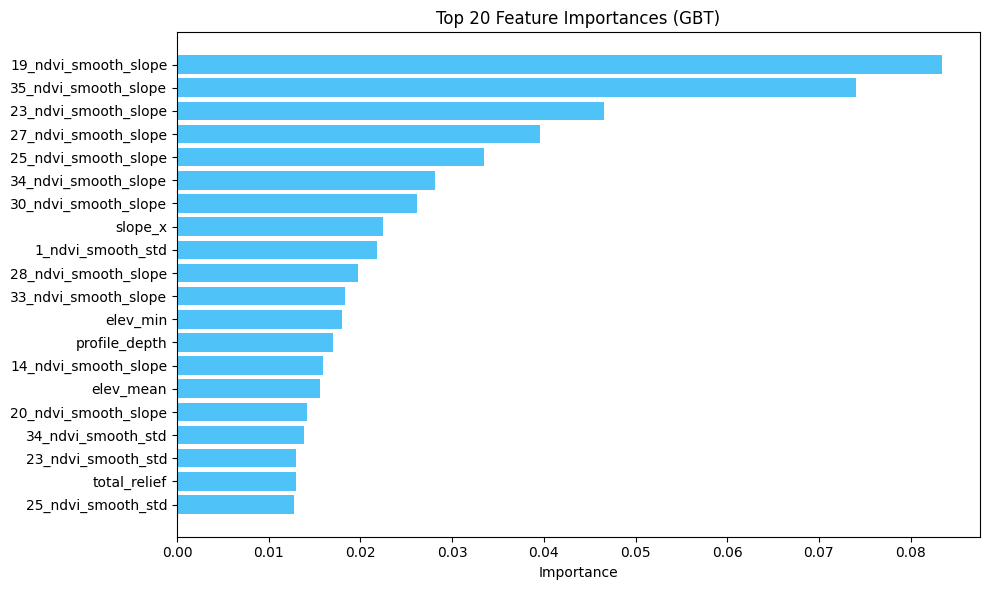

Saved gbt_feature_importances.png
             feature  importance
19_ndvi_smooth_slope    0.083395
35_ndvi_smooth_slope    0.074065
23_ndvi_smooth_slope    0.046603
27_ndvi_smooth_slope    0.039535
25_ndvi_smooth_slope    0.033488
34_ndvi_smooth_slope    0.028134
30_ndvi_smooth_slope    0.026200
             slope_x    0.022495
   1_ndvi_smooth_std    0.021801
28_ndvi_smooth_slope    0.019766
33_ndvi_smooth_slope    0.018371
            elev_min    0.017982
       profile_depth    0.016988
14_ndvi_smooth_slope    0.015924
           elev_mean    0.015588
20_ndvi_smooth_slope    0.014132
  34_ndvi_smooth_std    0.013804
  23_ndvi_smooth_std    0.013020
        total_relief    0.012946
  25_ndvi_smooth_std    0.012734


In [8]:

# GBT's own feature importances -- feature_importances.png elsewhere in this
# directory is RF-only; the site's headline R²=0.8950 stat is GBT's, so the
# public-facing chart should be GBT's importances, not RF's.
importances = gbt_model.stages[-1].featureImportances.toArray()
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top = feat_imp.head(20)
ax.barh(top['feature'][::-1], top['importance'][::-1], color='#4fc3f7')
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances (GBT)')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'gbt_feature_importances.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved gbt_feature_importances.png')
print(feat_imp.head(20).to_string(index=False))